To Build a model which predicts the Phase of the alloy with help of the properties so that we can build a better alloy using those properties


In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [163]:
df1 = pd.read_csv("C:\\Users\\Harish Immannavar\\Desktop\\CODING\\HEA.csv", encoding= 'Latin1')
print(df1)

        Alloy ID                     Alloy         Al        Co        Cr  \
0     Alloy 0000               Al0.5NbTaTiV  0.111111  0.000000  0.000000   
1     Alloy 0001              Al0.75MoNbTiV  0.157895  0.000000  0.000000   
2     Alloy 0002              Al0.25MoNbTiV  0.058824  0.000000  0.000000   
3     Alloy 0003              Al0.25NbTaTiV  0.058824  0.000000  0.000000   
4     Alloy 0004               Al0.2MoTaTiV  0.047619  0.000000  0.000000   
...          ...                        ...       ...       ...       ...   
1356  Alloy 1420               AlCoCrCuMnFe  0.142857  0.142857  0.142857   
1357  Alloy 1421  Al58.5Mg31.5Zn4.5Cu4.5Si1  0.584708  0.000000  0.000000   
1358  Alloy 1422      Al63Mg27Zn4.5Cu4.5Si1  0.629685  0.000000  0.000000   
1359  Alloy 1423  Al66.7Mg23.3Zn4.5Cu4.5Si1  0.666667  0.000000  0.000000   
1360         NaN                        NaN       NaN       NaN       NaN   

            Fe        Ni        Cu        Mn        Ti  ...  Quenching  HPR

In [164]:
df = df1.copy()

In [165]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1361 entries, 0 to 1360
Data columns (total 53 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alloy ID              1360 non-null   str    
 1   Alloy                 1360 non-null   str    
 2   Al                    1360 non-null   float64
 3   Co                    1360 non-null   float64
 4   Cr                    1360 non-null   float64
 5   Fe                    1360 non-null   float64
 6   Ni                    1360 non-null   float64
 7   Cu                    1360 non-null   float64
 8   Mn                    1360 non-null   float64
 9   Ti                    1360 non-null   float64
 10  V                     1360 non-null   float64
 11  Nb                    1360 non-null   float64
 12  Mo                    1360 non-null   float64
 13  Zr                    1360 non-null   float64
 14  Hf                    1360 non-null   float64
 15  Ta                    1360 non-n

In [166]:
print(df.shape)

(1361, 53)


In [167]:
# we will remove duplicates based on alloys column to remove the same alloys and to aavoid repetition
df.drop_duplicates(subset= 'Alloy ', inplace= True)

In [168]:
# now we will drop the alloy column as it will not have any effect on the target column
df.drop(columns= ['Alloy ','Alloy ID','References','Unnamed: 51','Unnamed: 52'], inplace= True)

In [169]:
print(df.duplicated().sum())

6


In [170]:
df.drop_duplicates(inplace = True)

In [171]:
df.nunique()

Al                       95
Co                       91
Cr                       90
Fe                       98
Ni                       93
Cu                       36
Mn                       50
Ti                       77
V                        58
Nb                       66
Mo                       53
Zr                       53
Hf                       40
Ta                       38
W                        19
C                        29
Mg                       13
Zn                       11
Si                       31
Re                        2
N                         3
Sc                        1
Li                        3
Sn                        3
Be                        1
Num_of_Elem               6
Density_calc            432
dHmix                   408
dSmix                   248
dGmix                   442
Tm                      435
n.Para                  441
Atom.Size.Diff          436
Elect.Diff              392
VEC                     307
Sythesis_Route      

In [172]:
df.drop(columns = ['Annealing_Time_(min)','Homogenization_Time','Homogenization_Temp','Hot-Cold_Working','Quenching','Annealing_Temp','HPR'],inplace = True)

In [173]:
df.duplicated().sum()

np.int64(10)

In [174]:
df.drop_duplicates(inplace =True)

In [175]:
df.drop(columns = ['Microstructure_','Microstructure','Multiphase','IM_Structure'],inplace = True)

In [176]:
df.dropna(inplace = True)

In [177]:

df.duplicated().sum()

np.int64(1)

In [178]:
df.drop_duplicates(inplace = True)

In [179]:

df.shape

(449, 37)

In [180]:
df.info()

<class 'pandas.DataFrame'>
Index: 449 entries, 0 to 1359
Data columns (total 37 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Al              449 non-null    float64
 1   Co              449 non-null    float64
 2   Cr              449 non-null    float64
 3   Fe              449 non-null    float64
 4   Ni              449 non-null    float64
 5   Cu              449 non-null    float64
 6   Mn              449 non-null    float64
 7   Ti              449 non-null    float64
 8   V               449 non-null    float64
 9   Nb              449 non-null    float64
 10  Mo              449 non-null    float64
 11  Zr              449 non-null    float64
 12  Hf              449 non-null    float64
 13  Ta              449 non-null    float64
 14  W               449 non-null    float64
 15  C               449 non-null    float64
 16  Mg              449 non-null    float64
 17  Zn              449 non-null    float64
 18  Si   

In [181]:
df['Phases'].value_counts()

Phases
BCC_SS          179
Im              164
FCC_SS           71
FCC_PLUS_BCC     35
Name: count, dtype: int64

In [182]:
df['Sythesis_Route'].value_counts()

Sythesis_Route
AC    428
PM     21
Name: count, dtype: int64

In [183]:
df.reset_index(inplace = True)

In [184]:
df.drop(columns = ['index'], inplace = True)

FEATURE CONSTRUCTION : Created new features from existing ones to capture additional information that may improve model performance on the basis of domain knowledge.

In [185]:
df['omega'] = (df['Tm']*df['dSmix'])/np.abs(df['dHmix'])

In [186]:
df['lambda'] = df['dSmix']/(df['Atom.Size.Diff']**2)

In [187]:
# Appending radii of different elements in the dataframe.
df['r_Al'] = 143
df['r_Co'] = 125
df['r_Cr'] = 128
df['r_Fe'] = 126
df['r_Ni'] = 124
df['r_Cu'] = 128
df['r_Mn'] = 127
df['r_Ti'] = 147
df['r_V'] = 134
df['r_Nb'] = 146
df['r_Mo'] = 139
df['r_Zr'] = 160
df['r_Hf'] = 159
df['r_Ta'] = 146
df['r_W'] = 139
df['r_C'] = 75
df['r_Mg'] = 160
df['r_Zn'] = 134
df['r_Si'] = 116
df['r_Re'] = 137
df['r_N'] = 71
df['r_Sc'] = 162
df['r_Li'] = 152
df['r_Sn'] = 140
df['r_Be'] = 112

In [188]:
df['r_avg'] = (df['Al']*df['r_Al']) + (df['Co']*df['r_Co']) + (df['Cr']*df['r_Cr']) + (df['Fe']*df['r_Fe']) + (df['Ni']*df['r_Ni']) + (df['Cu']*df['r_Cu']) + (df['Mn']*df['r_Mn']) + (df['Ti']*df['r_Ti']) + (df['V']*df['r_V']) + (df['Nb']*df['r_Nb']) + (df['Mo']*df['r_Mo']) + (df['Zr']*df['r_Zr']) + (df['Hf']*df['r_Hf']) + (df['Ta']*df['r_Ta']) + (df['W']*df['r_W']) + (df['C']*df['r_C']) + (df['Mg']*df['r_Mg']) + (df['Zn']*df['r_Zn']) + (df['Si']*df['r_Si']) + (df['Re']*df['r_Re']) + (df['N']*df['r_N']) + (df['Sc']*df['r_Sc']) + (df['Li']*df['r_Li']) + (df['Sn']*df['r_Sn']) + (df['Be']*df['r_Be'])

In [189]:
df2 = df.iloc[:,0:25]
df2

,Al,Co,Cr,Fe,Ni,Cu,Mn,Ti,V,Nb,...,C,Mg,Zn,Si,Re,N,Sc,Li,Sn,Be
0,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.222222,0.222222,0.222222,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.157895,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.210526,0.210526,0.210526,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.058824,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.235294,0.235294,0.235294,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.058824,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.235294,0.235294,0.235294,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.047619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.238095,0.238095,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,0.142857,0.142857,0.142857,0.142857,0.000000,0.142857,0.142857,0.142857,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
445,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
446,0.584708,0.000000,0.000000,0.000000,0.000000,0.045477,0.000000,0.000000,0.000000,0.000000,...,0.0,0.314843,0.044978,0.009995,0.0,0.0,0.0,0.0,0.0,0.0
447,0.629685,0.000000,0.000000,0.000000,0.000000,0.045477,0.000000,0.000000,0.000000,0.000000,...,0.0,0.269865,0.044978,0.009995,0.0,0.0,0.0,0.0,0.0,0.0


In [190]:
# Fetching radius of all elements
df3 = df.iloc[:,39:64]
df3

,r_Al,r_Co,r_Cr,r_Fe,r_Ni,r_Cu,r_Mn,r_Ti,r_V,r_Nb,...,r_C,r_Mg,r_Zn,r_Si,r_Re,r_N,r_Sc,r_Li,r_Sn,r_Be
0,143,125,128,126,124,128,127,147,134,146,...,75,160,134,116,137,71,162,152,140,112
1,143,125,128,126,124,128,127,147,134,146,...,75,160,134,116,137,71,162,152,140,112
2,143,125,128,126,124,128,127,147,134,146,...,75,160,134,116,137,71,162,152,140,112
3,143,125,128,126,124,128,127,147,134,146,...,75,160,134,116,137,71,162,152,140,112
4,143,125,128,126,124,128,127,147,134,146,...,75,160,134,116,137,71,162,152,140,112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,143,125,128,126,124,128,127,147,134,146,...,75,160,134,116,137,71,162,152,140,112
445,143,125,128,126,124,128,127,147,134,146,...,75,160,134,116,137,71,162,152,140,112
446,143,125,128,126,124,128,127,147,134,146,...,75,160,134,116,137,71,162,152,140,112
447,143,125,128,126,124,128,127,147,134,146,...,75,160,134,116,137,71,162,152,140,112


In [191]:
#Code for selecting the largest and smallest atom in the alloy
r_min = []
r_max = []
for i in range(df2.shape[0]):
  a= []
  for j in range(df2.shape[1]):
    if df2.iloc[i, j] != 0:
      a.append(df3.iloc[i, j])
  r_min.append(min(a))
  r_max.append(max(a))
df['r_minimum'] = r_min
df['r_maximum'] = r_max

In [192]:

df['gamma'] = (1 - np.sqrt(((df['r_minimum'] + df['r_avg'])**2 - ((df['r_avg'])**2))/(df['r_minimum'] + df['r_avg'])**2))/(1 - np.sqrt(((df['r_maximum'] + df['r_avg'])**2 - ((df['r_avg'])**2))/(df['r_maximum'] + df['r_avg'])**2))

Now since we for each row, we have found out minimum , maximum and average radii, so now we can drop the columns containing radii of individual elements

In [193]:

df.drop(columns = df.iloc[:,39:64], inplace = True)

In [194]:

df

,Al,Co,Cr,Fe,Ni,Cu,Mn,Ti,V,Nb,...,Elect.Diff,VEC,Sythesis_Route,Phases,omega,lambda,r_avg,r_minimum,r_maximum,gamma
0,0.111111,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.222222,0.222222,0.222222,...,0.049616,4.555556,AC,BCC_SS,3469.803740,0.941084,143.222222,134,147,1.103983
1,0.157895,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.210526,0.210526,0.210526,...,0.232765,4.684211,AC,BCC_SS,2730.618206,0.893300,141.736842,134,147,1.104455
2,0.058824,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.235294,0.235294,0.235294,...,0.243217,4.882353,AC,BCC_SS,6597.555141,0.792925,141.588235,134,147,1.104502
3,0.058824,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.235294,0.235294,0.235294,...,0.050176,4.647059,AC,BCC_SS,6102.098558,0.865245,143.235294,134,147,1.103979
4,0.047619,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.238095,0.238095,0.000000,...,0.244333,4.904762,AC,BCC_SS,7937.803591,0.778630,141.571429,134,147,1.104508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
444,0.142857,0.142857,0.142857,0.142857,0.000000,0.142857,0.142857,0.142857,0.000000,0.000000,...,0.146969,6.666667,AC,Im,1465.695546,0.367822,132.000000,125,147,1.193110
445,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.142857,0.000000,0.000000,0.000000,...,0.137042,7.333333,AC,FCC_PLUS_BCC,4975.267462,0.523002,128.714286,124,143,1.168513
446,0.584708,0.000000,0.000000,0.000000,0.000000,0.045477,0.000000,0.000000,0.000000,0.000000,...,0.160000,3.460000,AC,Im,2001.176118,0.217663,146.995502,116,160,1.398872
447,0.629685,0.000000,0.000000,0.000000,0.000000,0.045477,0.000000,0.000000,0.000000,0.000000,...,0.160000,3.510000,AC,Im,2070.503490,0.226904,146.230884,116,160,1.399907


FEATURE ENCODING : Converted categorical variables into a numerical format suitable for modeling.

Since we are having two categorical columns namely 'Phases' and 'Sythesis_Route' so we will encode them.

In [195]:
df['Phases'].value_counts()

Phases
BCC_SS          179
Im              164
FCC_SS           71
FCC_PLUS_BCC     35
Name: count, dtype: int64

In [196]:
df['Sythesis_Route'].value_counts()

Sythesis_Route
AC    428
PM     21
Name: count, dtype: int64

In [197]:
df['Phases'] = df['Phases'].replace({
    'BCC_SS': 0,
    'FCC_SS': 1,
    'FCC_PLUS_BCC': 2,
    'Im': 3
}).astype(int)

df['Sythesis_Route'] = df['Sythesis_Route'].replace({
    'AC': 0,
    'PM': 1
}).astype(int)

In [198]:
df['Phases'].value_counts()

Phases
0    179
3    164
1     71
2     35
Name: count, dtype: int64

In [199]:

df['Sythesis_Route'].value_counts()

Sythesis_Route
0    428
1     21
Name: count, dtype: int64

In [200]:
# now as all the columns are numerical we can check the coorelation with the output

df.corr()['Phases']

Al                0.322865
Co                0.249734
Cr                0.295399
Fe                0.379428
Ni                0.347063
Cu                0.167174
Mn                0.160923
Ti               -0.460451
V                -0.225813
Nb               -0.457486
Mo               -0.320042
Zr               -0.419488
Hf               -0.303857
Ta               -0.387359
W                -0.074465
C                 0.114679
Mg                0.153235
Zn                0.162385
Si                0.187380
Re                0.056476
N                -0.034414
Sc                     NaN
Li                0.079958
Sn                0.068523
Be                     NaN
Num_of_Elem       0.226209
Density_calc     -0.355181
dHmix            -0.331343
dSmix            -0.063787
dGmix            -0.548706
Tm               -0.546515
n.Para           -0.173727
Atom.Size.Diff    0.125072
Elect.Diff       -0.173887
VEC               0.353115
Sythesis_Route    0.074487
Phases            1.000000
o

In [201]:

df.drop(columns = ['W','Re','N','Sc','Be','Sn','Li'], inplace= True) 
# We cannot drop columns namely 'dSmix', 'lambda' and 'Sythesis_Route' beacuse they are important for our analysis as they are major factors for Phase prediction.


DATA VISUALISATION

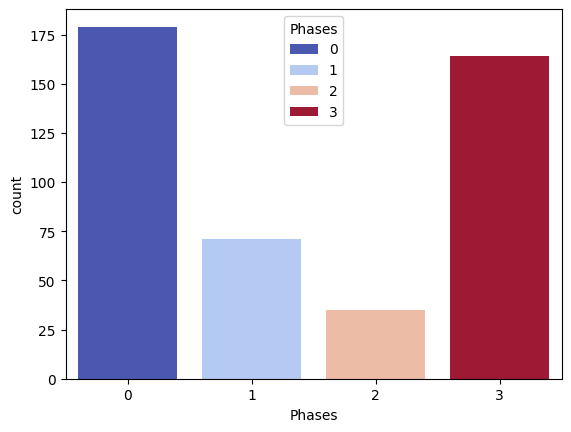

In [202]:
sns.countplot(x = df['Phases'], hue = df['Phases'], palette = 'coolwarm')
plt.show()

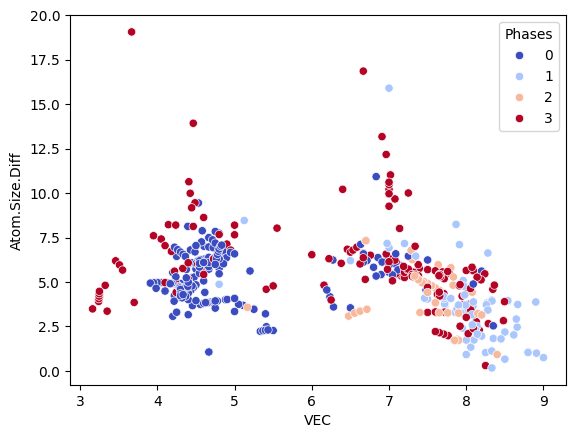

In [203]:
sns.scatterplot(data = df, x= 'VEC', y='Atom.Size.Diff', hue='Phases', palette= 'coolwarm')
plt.show()

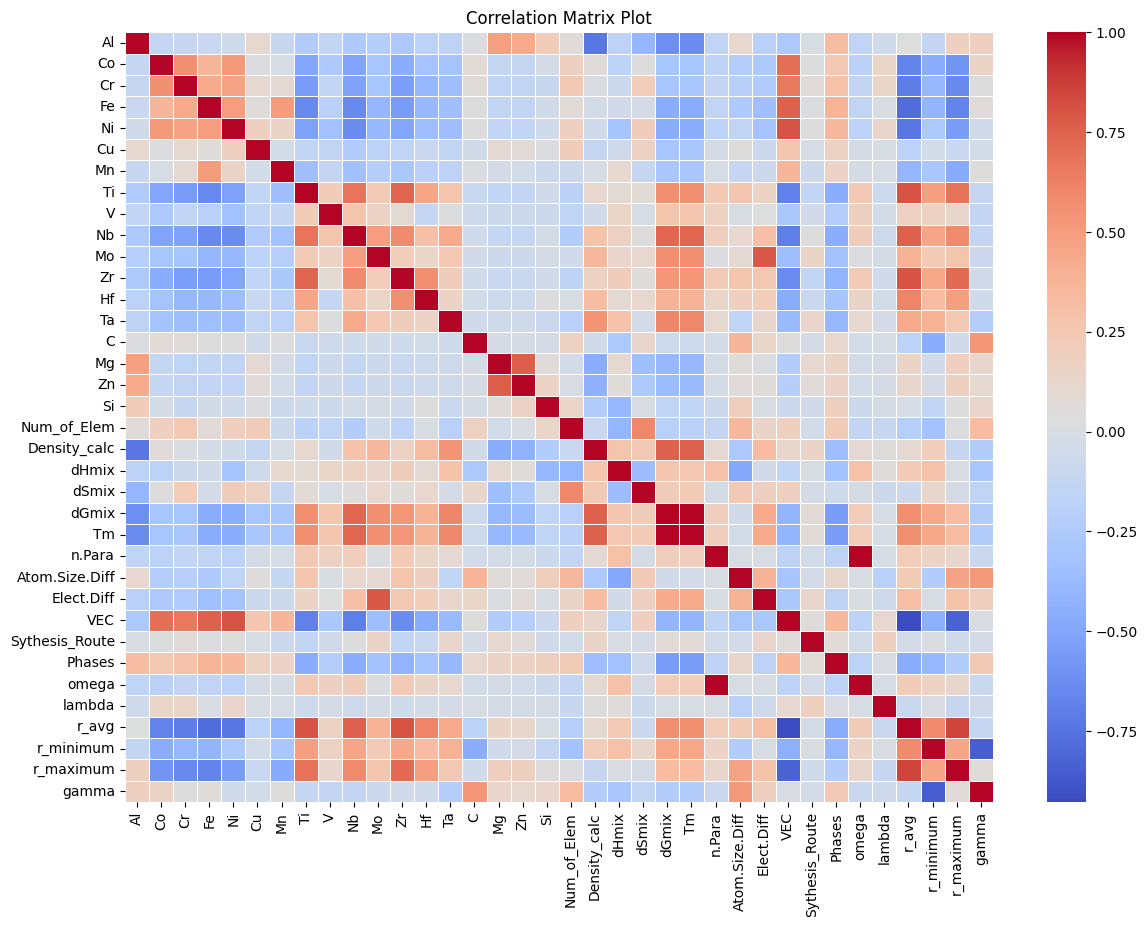

In [204]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Plot')
plt.show()

SCALING AND PREDICTION OF PHASES


In [205]:
x = df.drop(columns = ['Phases'])
y = df['Phases']
print(x.shape)

(449, 35)


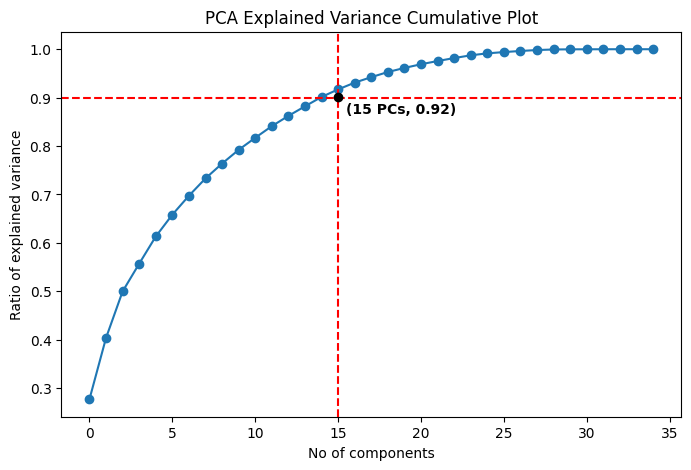

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#Step 1: Separate features and target 
x = df.drop(columns=['Phases'])
y = df['Phases']

#Step 2: Split data with CRUCIAL Stratification
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  
) 

#Step 3: Standard Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

#Step 4: Variance Elbow Plot (To verify your 14 components)
pca_check = PCA(n_components=None)
pca_check.fit(x_train_scaled)

cumulative_explained_variance = np.cumsum(pca_check.explained_variance_ratio_)
num_components = np.argmax(cumulative_explained_variance >= 0.9)+1

plt.figure(figsize=(8, 5))
plt.plot(cumulative_explained_variance, marker='o', linestyle='-')
plt.axhline(y=0.9, color='red', linestyle='--')
plt.axvline(x=num_components, color='red', linestyle='--')
plt.scatter(num_components, cumulative_explained_variance[num_components-1], color='black', zorder=5)
plt.text(num_components + 0.5, cumulative_explained_variance[num_components] - 0.05, 
         f'({num_components} PCs, {cumulative_explained_variance[num_components]:.2f})', color='black', weight='bold')
plt.xlabel('No of components')
plt.ylabel('Ratio of explained variance')
plt.title('PCA Explained Variance Cumulative Plot')
plt.show()

#Step 5: Actual PCA Transformation 
pca = PCA(n_components=num_components)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)



MODEL TRAINING, EVALUATION AND SELECTION

In [207]:
from sklearn.linear_model import LogisticRegression
softmax_regressor = LogisticRegression()
softmax_regressor.fit(x_train_pca, y_train)
y_pred = softmax_regressor.predict(x_test_pca)
print('accuracy score:', accuracy_score(y_test,y_pred))

accuracy score: 0.6333333333333333


In [208]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train_pca,y_train)
y_pred = dt.predict(x_test_pca)
print('accuracy score:', accuracy_score(y_test,y_pred))

accuracy score: 0.6222222222222222


In [209]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train_pca,y_train)
y_pred = rf.predict(x_test_pca)
print('accuracy score:', accuracy_score(y_test,y_pred))

accuracy score: 0.6777777777777778


In [210]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_train_pca, y_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(x_test_pca)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(test_accuracy))

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters found:  {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation accuracy: 0.79
Test set accuracy: 0.68


In [211]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train_pca,y_train)
y_pred = xgb.predict(x_test_pca)
print('accuracy score:', accuracy_score(y_test,y_pred))

accuracy score: 0.6888888888888889


In [212]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier


final_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,       
    max_depth=4,              
    subsample=0.7,            
    colsample_bytree=0.7,     
    reg_alpha=0.1,            
    reg_lambda=1.0,           
    random_state=42,
    eval_metric='mlogloss'
)


final_xgb.fit(x_train_pca,y_train)


y_pred_final = final_xgb.predict(x_test_pca)
test_acc = accuracy_score(y_test, y_pred_final)


print(f" New Regularized Test Accuracy: {test_acc * 100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final, target_names=['BCC_SS','FCC_SS','FCC_PLUS_BCC','Im']))

 New Regularized Test Accuracy: 67.78%

Classification Report:

              precision    recall  f1-score   support

      BCC_SS       0.85      0.64      0.73        36
      FCC_SS       0.65      0.79      0.71        14
FCC_PLUS_BCC       0.50      0.57      0.53         7
          Im       0.61      0.70      0.65        33

    accuracy                           0.68        90
   macro avg       0.65      0.67      0.66        90
weighted avg       0.70      0.68      0.68        90



Now we will use K-Neighbors Classifier and then apply hyperparameter tuning.

In [213]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train_pca, y_train)
y_pred = knn.predict(x_test_pca)
print('accuracy score:', accuracy_score(y_test,y_pred))

accuracy score: 0.6555555555555556


In [214]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']  
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_train_pca, y_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(x_test_pca)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(test_accuracy))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best cross-validation accuracy: 0.75
Test set accuracy: 0.69


In [215]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(x_train_pca,y_train)
y_pred = svc.predict(x_test_pca)
print('accuracy score:', accuracy_score(y_test,y_pred))

accuracy score: 0.6111111111111112


In [216]:
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001],  # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid']  # Kernel type
}

svm = SVC()

grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_train_pca,y_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(x_test_pca)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(test_accuracy))

Fitting 5 folds for each of 64 candidates, totalling 320 fits


Best parameters found:  {'C': 1, 'gamma': 0.1, 'kernel': 'poly'}
Best cross-validation accuracy: 0.76
Test set accuracy: 0.71


Addressing Imbalanced Data :

Recognized the presence of a class imbalance in the dataset, which could skew model predictions.
Implemented oversampling using SMOTE (Synthetic Minority Over-sampling Technique) to balance the class distribution..

In [217]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

In [218]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled_sm = scaler.fit_transform(x_train_smote)
x_test_scaled1 = scaler.transform(x_test)

In [219]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(x_train_scaled_sm, y_train_smote)
y_pred = rf.predict(x_test_scaled1)
accuracy_score(y_test, y_pred)

0.6666666666666666

In [220]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_train_scaled_sm, y_train_smote)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(x_test_scaled1)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(test_accuracy))

Fitting 5 folds for each of 162 candidates, totalling 810 fits


Best parameters found:  {'bootstrap': False, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.89
Test set accuracy: 0.69


In [221]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train_scaled_sm, y_train_smote)
y_pred = xgb.predict(x_test_scaled1)
print('accuracy score:', accuracy_score(y_test,y_pred))

accuracy score: 0.6888888888888889


In [222]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_train_scaled_sm, y_train_smote)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(x_test_scaled1)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(test_accuracy))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


c:\Users\Harish Immannavar\Desktop\CODING\myenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:11:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found:  {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Best cross-validation accuracy: 0.88
Test set accuracy: 0.69


In [223]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(x_train_scaled_sm, y_train_smote  )
y_pred = knn.predict(x_test_scaled1)
print('accuracy score:', accuracy_score(y_test,y_pred))

accuracy score: 0.6888888888888889


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],  
    'weights': ['uniform', 'distance'],  
    'metric': ['euclidean', 'manhattan', 'minkowski']  
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_train_scaled_sm, y_train_smote)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(x_test_scaled1)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(test_accuracy))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


Best parameters found:  {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best cross-validation accuracy: 0.88
Test set accuracy: 0.67


In [225]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(x_train_scaled_sm, y_train_smote)
y_pred = svc.predict(x_test_scaled1)
print('accuracy score:', accuracy_score(y_test,y_pred))

accuracy score: 0.6111111111111112


In [226]:
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001],  # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid']  # Kernel type
}

svm = SVC()

grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_train_scaled_sm, y_train_smote)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(x_test_scaled1)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(test_accuracy))



print(f" New Regularized Test Accuracy: {test_accuracy * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['BCC_SS','FCC_SS','FCC_PLUS_BCC','Im']))

Fitting 5 folds for each of 64 candidates, totalling 320 fits


Best parameters found:  {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.88
Test set accuracy: 0.76
 New Regularized Test Accuracy: 75.56%

Classification Report:

              precision    recall  f1-score   support

      BCC_SS       0.88      0.81      0.84        36
      FCC_SS       0.71      0.71      0.71        14
FCC_PLUS_BCC       0.55      0.86      0.67         7
          Im       0.72      0.70      0.71        33

    accuracy                           0.76        90
   macro avg       0.71      0.77      0.73        90
weighted avg       0.77      0.76      0.76        90



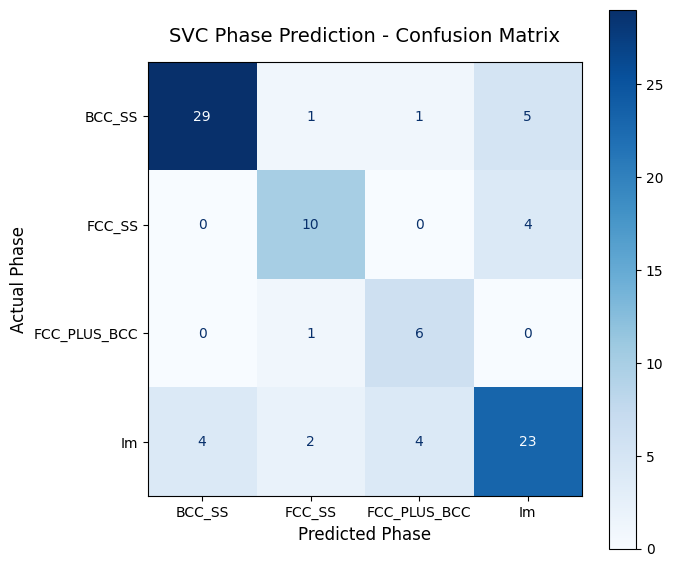

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred_svc = best_svm.predict(x_test_scaled1) 


cm = confusion_matrix(y_test, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BCC_SS','FCC_SS','FCC_PLUS_BCC','Im'])

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("SVC Phase Prediction - Confusion Matrix", fontsize=14, pad=15)
plt.ylabel('Actual Phase', fontsize=12)
plt.xlabel('Predicted Phase', fontsize=12)
plt.show()



In [228]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size = 0.20,random_state = 42)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [229]:
from imblearn.over_sampling import SMOTE
# 3. SMOTE ONLY THE TRAINING DATA
sm = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = sm.fit_resample(x_train_scaled, y_train)

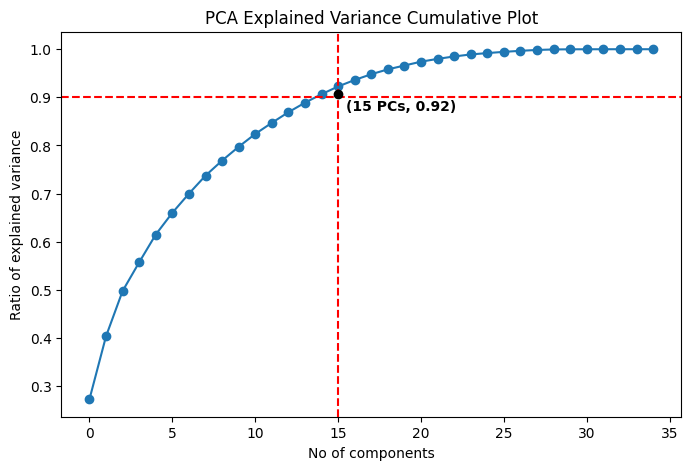

In [ ]:
pca_check = PCA(n_components=None)
pca_check.fit(x_train_scaled)

cumulative_explained_variance = np.cumsum(pca_check.explained_variance_ratio_)
num_components = np.argmax(cumulative_explained_variance >= 0.9)+1

plt.figure(figsize=(8, 5))
plt.plot(cumulative_explained_variance, marker='o', linestyle='-')
plt.axhline(y=0.9, color='red', linestyle='--')
plt.axvline(x=num_components, color='red', linestyle='--')
plt.scatter(num_components, cumulative_explained_variance[num_components-1], color='black', zorder=5)
plt.text(num_components + 0.5, cumulative_explained_variance[num_components] - 0.05, 
         f'({num_components} PCs, {cumulative_explained_variance[num_components]:.2f})', color='black', weight='bold')
plt.xlabel('No of components')
plt.ylabel('Ratio of explained variance')
plt.title('PCA Explained Variance Cumulative Plot')
plt.show()

#Step 5: Actual PCA Transformation 
pca = PCA(n_components=num_components)
x_train_pca = pca.fit_transform(x_train_resampled)
x_test_pca = pca.transform(x_test_scaled)


In [231]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(x_train_pca, y_train_resampled)
y_pred = xgb.predict(x_test_pca)
print('accuracy score:', accuracy_score(y_test,y_pred))

accuracy score: 0.7333333333333333


In [232]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_train_pca, y_train_resampled)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(x_test_pca)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(test_accuracy))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


c:\Users\Harish Immannavar\Desktop\CODING\myenv\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:15:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found:  {'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 50, 'subsample': 0.8}
Best cross-validation accuracy: 0.85
Test set accuracy: 0.74


In [233]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(x_train_pca, y_train_resampled)
y_pred = rf.predict(x_test_pca)
accuracy_score(y_test, y_pred)

0.7333333333333333

In [238]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_train_pca, y_train_resampled)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(x_test_pca)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(test_accuracy))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['BCC_SS','FCC_SS','FCC_PLUS_BCC','Im']))

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters found:  {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation accuracy: 0.85
Test set accuracy: 0.78

Classification Report:

              precision    recall  f1-score   support

      BCC_SS       0.80      0.85      0.82        33
      FCC_SS       0.87      0.81      0.84        16
FCC_PLUS_BCC       0.44      0.57      0.50         7
          Im       0.81      0.74      0.77        34

    accuracy                           0.78        90
   macro avg       0.73      0.74      0.73        90
weighted avg       0.79      0.78      0.78        90



In [ ]:
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001],  # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid'],  # Kernel type
    'class_weight': ['balanced', None]
}

svm = SVC()

grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

grid_search.fit(x_train_pca, y_train_resampled)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.2f}".format(grid_search.best_score_))
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(x_test_pca)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.2f}".format(test_accuracy))


print(f" New Regularized Test Accuracy: {test_accuracy * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['BCC_SS','FCC_SS','FCC_PLUS_BCC','Im']))

Fitting 5 folds for each of 128 candidates, totalling 640 fits
Best parameters found:  {'C': 10, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation accuracy: 0.83
Test set accuracy: 0.74
 New Regularized Test Accuracy: 74.44%

Classification Report:

              precision    recall  f1-score   support

      BCC_SS       0.77      0.82      0.79        33
      FCC_SS       0.75      0.75      0.75        16
FCC_PLUS_BCC       0.57      0.57      0.57         7
          Im       0.75      0.71      0.73        34

    accuracy                           0.74        90
   macro avg       0.71      0.71      0.71        90
weighted avg       0.74      0.74      0.74        90



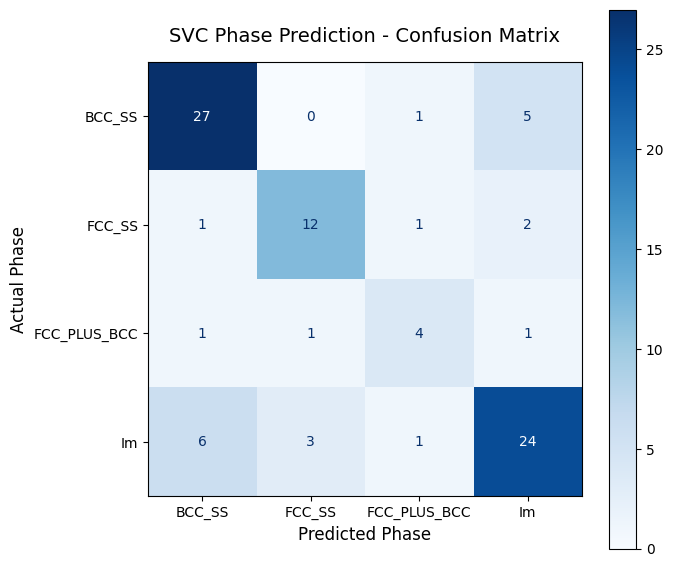

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred_svc = best_svm.predict(x_test_pca)


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BCC_SS','FCC_SS','FCC_PLUS_BCC','Im'])

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("SVC Phase Prediction - Confusion Matrix", fontsize=14, pad=15)
plt.ylabel('Actual Phase', fontsize=12)
plt.xlabel('Predicted Phase', fontsize=12)
plt.show()

So we can conclude that earlier we got an accuracy around 65% for only using PCA and SMOTE individually, but when we combined them both we got highest accuracy of 78% using the Random Forest with hyper parameter tuning.